In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
world_ranking= pd.read_csv("fifa_ranking_2022-10-06.csv")
world_cup= pd.read_csv("world_cup.csv")
matches = pd.read_csv("matches_1930_2022.csv")

In [5]:
world_ranking.head()

,team,team_code,association,rank,previous_rank,points,previous_points
0,Brazil,BRA,CONMEBOL,1,1,1841.30,1837.56
1,Belgium,BEL,UEFA,2,2,1816.71,1821.92
2,Argentina,ARG,CONMEBOL,3,3,1773.88,1770.65
3,France,FRA,UEFA,4,4,1759.78,1764.85
4,England,ENG,UEFA,5,5,1728.47,1737.46


In [6]:
world_cup.head()

,Year,Host,Teams,Champion,Runner-Up,TopScorrer,Attendance,AttendanceAvg,Matches
0,2022,Qatar,32,Argentina,France,Kylian Mbappé - 8,3404252,53191,64
1,2018,Russia,32,France,Croatia,Harry Kane - 6,3031768,47371,64
2,2014,Brazil,32,Germany,Argentina,James Rodríguez - 6,3429873,53592,64
3,2010,South Africa,32,Spain,Netherlands,"Wesley Sneijder, Thomas Müller... - 5",3178856,49670,64
4,2006,Germany,32,Italy,France,Miroslav Klose - 5,3352605,52384,64


In [7]:
matches.head()

,home_team,away_team,home_score,home_xg,home_penalty,away_score,away_xg,away_penalty,home_manager,home_captain,...,home_penalty_shootout_miss_long,away_penalty_shootout_miss_long,home_red_card,away_red_card,home_yellow_red_card,away_yellow_red_card,home_yellow_card_long,away_yellow_card_long,home_substitute_in_long,away_substitute_in_long
0,Argentina,France,3,3.3,4.0,3,2.2,2.0,Lionel Scaloni,Lionel Messi,...,NaN,"['3|1:1|Kingsley Coman', '5|2:1|Aurélien Tchou...",NaN,NaN,NaN,NaN,"['45+7&rsquor;|2:0|Enzo Fernández', '90+8&rsqu...","['55&rsquor;|2:0|Adrien Rabiot', '87&rsquor;|2...",['64&rsquor;|2:0|Marcos Acuña|for Ángel Di Mar...,['41&rsquor;|2:0|Randal Kolo Muani|for Ousmane...
1,Croatia,Morocco,2,0.7,NaN,1,1.2,NaN,Zlatko Dalić,Luka Modrić,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['69&rsquor;|2:1|Azzedine Ounahi', '84&rsquor;...",['61&rsquor;|2:1|Nikola Vlašić|for Andrej Kram...,['46&rsquor;|2:1|Ilias Chair|for Abdelhamid Sa...
2,France,Morocco,2,2.0,NaN,0,0.9,NaN,Didier Deschamps,Hugo Lloris,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['27&rsquor;|1:0|Sofiane Boufal'],['65&rsquor;|1:0|Marcus Thuram|for Olivier Gir...,['21&rsquor;|1:0|Selim Amallah|for Romain Saïs...
3,Argentina,Croatia,3,2.3,NaN,0,0.5,NaN,Lionel Scaloni,Lionel Messi,...,NaN,NaN,NaN,NaN,NaN,NaN,"['68&rsquor;|2:0|Cristian Romero', '71&rsquor;...","['32&rsquor;|0:0|Mateo Kovačić', '32&rsquor;|0...",['62&rsquor;|2:0|Lisandro Martínez|for Leandro...,"['46&rsquor;|2:0|Mislav Oršić|for Borna Sosa',..."
4,Morocco,Portugal,1,1.4,NaN,0,0.9,NaN,Hoalid Regragui,Romain Saïss,...,NaN,NaN,NaN,NaN,Walid Cheddira · 90+3,NaN,"['70&rsquor;|1:0|Achraf Dari', '90+1&rsquor;|1...",['87&rsquor;|1:0|Vitinha'],['57&rsquor;|1:0|Achraf Dari|for Romain Saïss'...,['51&rsquor;|1:0|João Cancelo|for Raphaël Guer...


In [8]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 964 entries, 0 to 963
Data columns (total 44 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   home_team                        964 non-null    object 
 1   away_team                        964 non-null    object 
 2   home_score                       964 non-null    int64  
 3   home_xg                          128 non-null    float64
 4   home_penalty                     35 non-null     float64
 5   away_score                       964 non-null    int64  
 6   away_xg                          128 non-null    float64
 7   away_penalty                     35 non-null     float64
 8   home_manager                     964 non-null    object 
 9   home_captain                     644 non-null    object 
 10  away_manager                     964 non-null    object 
 11  away_captain                     644 non-null    object 
 12  Attendance            

In [9]:
matches['home_substitute_in_long'][0]

"['64&rsquor;|2:0|Marcos Acuña|for Ángel Di María', '91&rsquor;|2:2|Gonzalo Montiel|for Nahuel Molina', '102&rsquor;|2:2|Leandro Paredes|for Rodrigo De Paul', '103&rsquor;|2:2|Lautaro Martínez|for Julián Álvarez', '116&rsquor;|3:2|Germán Pezzella|for Alexis Mac Allister', '120+1&rsquor;|3:3|Paulo Dybala|for Nicolás Tagliafico']"

In [10]:
print(matches.shape)
print(world_cup.shape)
print(world_ranking.shape)

(964, 44)
(22, 9)
(211, 7)


In [11]:
#Checking for Null values
matches.isnull().sum()/len(matches)*100

home_team                           0.000000
away_team                           0.000000
home_score                          0.000000
home_xg                            86.721992
home_penalty                       96.369295
away_score                          0.000000
away_xg                            86.721992
away_penalty                       96.369295
home_manager                        0.000000
home_captain                       33.195021
away_manager                        0.000000
away_captain                       33.195021
Attendance                          0.000000
Venue                               0.000000
Officials                          26.452282
Round                               0.000000
Date                                0.000000
Score                               0.000000
Referee                            26.452282
Notes                              92.427386
Host                                0.000000
Year                                0.000000
home_goal 

In [12]:
world_ranking.isnull().sum()

team               0
team_code          0
association        0
rank               0
previous_rank      0
points             0
previous_points    0
dtype: int64

In [13]:
world_cup.isnull().sum()

Year             0
Host             0
Teams            0
Champion         0
Runner-Up        0
TopScorrer       0
Attendance       0
AttendanceAvg    0
Matches          0
dtype: int64

In [14]:
print(matches.duplicated().sum())
print(world_ranking.duplicated().sum())
print(world_cup.duplicated().sum())

0
0
0


In [15]:
matches['home_team'].unique()

array(['Argentina', 'Croatia', 'France', 'Morocco', 'England',
       'Netherlands', 'Portugal', 'Japan', 'Brazil', 'Korea Republic',
       'Ghana', 'Cameroon', 'Serbia', 'Canada', 'Costa Rica', 'Australia',
       'Tunisia', 'Saudi Arabia', 'Poland', 'Ecuador', 'IR Iran', 'Wales',
       'Belgium', 'Spain', 'Qatar', 'Switzerland', 'Uruguay', 'Germany',
       'Denmark', 'Mexico', 'Senegal', 'United States', 'Sweden',
       'Russia', 'Colombia', 'Panama', 'Iceland', 'Nigeria', 'Peru',
       'Egypt', 'Algeria', 'Bosnia and Herzegovina', 'Honduras', 'Italy',
       'Greece', "Côte d'Ivoire", 'Chile', 'Paraguay', 'Korea DPR',
       'Slovakia', 'Slovenia', 'South Africa', 'New Zealand', 'Ukraine',
       'Togo', 'Czech Republic', 'Serbia and Montenegro', 'Angola',
       'Trinidad and Tobago', 'Türkiye', 'China PR',
       'Republic of Ireland', 'Romania', 'Scotland', 'FR Yugoslavia',
       'Jamaica', 'Bulgaria', 'Bolivia', 'Norway', 'West Germany',
       'Yugoslavia', 'Czechoslovaki

# west germany or Germany DR - 1949 - 1990

In [16]:
matches['home_team']= matches['home_team'].apply(lambda x: x.replace("Germany DR", " West Germany"))
matches['away_team']= matches['away_team'].apply(lambda x: x.replace("Germany DR", " West Germany"))

In [17]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 964 entries, 0 to 963
Data columns (total 44 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   home_team                        964 non-null    object 
 1   away_team                        964 non-null    object 
 2   home_score                       964 non-null    int64  
 3   home_xg                          128 non-null    float64
 4   home_penalty                     35 non-null     float64
 5   away_score                       964 non-null    int64  
 6   away_xg                          128 non-null    float64
 7   away_penalty                     35 non-null     float64
 8   home_manager                     964 non-null    object 
 9   home_captain                     644 non-null    object 
 10  away_manager                     964 non-null    object 
 11  away_captain                     644 non-null    object 
 12  Attendance            

In [18]:
# Total number of matches played till 2022.
print(f'Total Number of matches : {len(matches)}')

# Total goals Scored (penalty Goals).
print(f"Total goals scored: {sum(matches['home_score'] + matches['away_score'])}")

#Average Goals Scored Per match.
print(f"Avg goals scored per match:{sum(matches['home_score'] + matches['away_score'])/len(matches)}")

#Total attendance Over time.
print(f"Total attendance Over time: {sum(matches['Attendance'])}")

#Average aattendance Over time.
print(f"Average aattendance Over time: {sum(matches['Attendance'])/len(matches)}")

Total Number of matches : 964
Total goals scored: 2720
Avg goals scored per match:2.8215767634854774
Total attendance Over time: 44048413
Average aattendance Over time: 45693.3744813278


# Times a Particular country is winner , First runner up or  Second Runner up

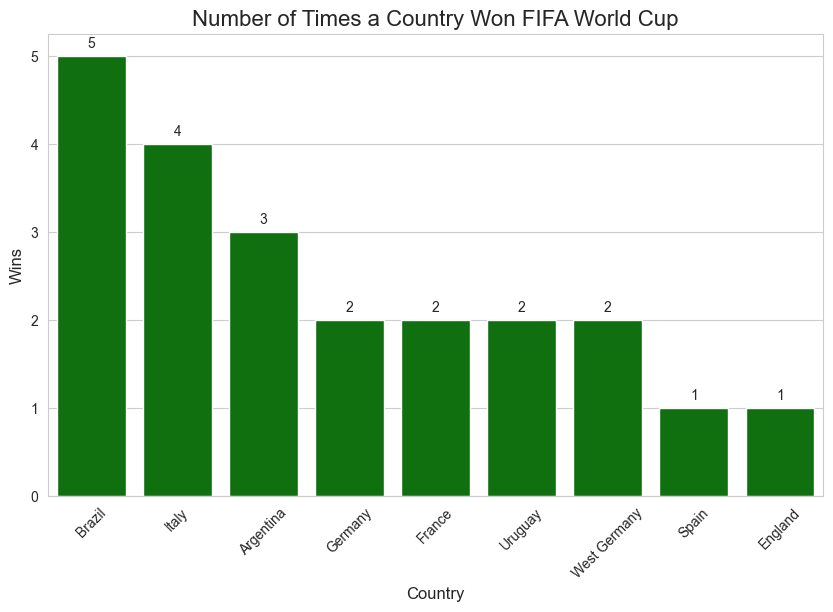

In [20]:
winner = world_cup['Champion'].value_counts().reset_index()

winner.columns = ['Champion', 'count']

sns.set_style("whitegrid")


plt.figure(figsize=(10,6))

sns.barplot(data=winner,x='Champion',y='count',color='green')
plt.title('Number of Times a Country Won FIFA World Cup', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Wins', fontsize=12)

plt.xticks(rotation=45)
for index, value in enumerate(winner['count']):
    plt.text(index, value + 0.1, str(value), ha='center')

plt.show()

In [21]:
winner

,Champion,count
0,Brazil,5
1,Italy,4
2,Argentina,3
3,Germany,2
4,France,2
5,Uruguay,2
6,West Germany,2
7,Spain,1
8,England,1


# FIRST RUNNER UP AND SECOND RUNNER UP

In [22]:
matches['Round'].unique()

array(['Final', 'Third-place match', 'Semi-finals', 'Quarter-finals',
       'Round of 16', 'Group stage', 'Second group stage',
       'First group stage', 'Second round', 'First round',
       'Group stage play-off', 'Final stage'], dtype=object)

In [23]:
matches['home_penalty'].fillna(0, inplace=True)
matches['away_penalty'].fillna(0, inplace=True)

In [24]:
matches['h_total']= matches['home_score'] + matches['home_penalty']
matches['a_total']= matches['away_score'] + matches['away_penalty']

In [25]:
Runner = matches[matches['Round']=='Final']
Third = matches[matches['Round']=='Third-place match']
Runner

,home_team,away_team,home_score,home_xg,home_penalty,away_score,away_xg,away_penalty,home_manager,home_captain,...,home_red_card,away_red_card,home_yellow_red_card,away_yellow_red_card,home_yellow_card_long,away_yellow_card_long,home_substitute_in_long,away_substitute_in_long,h_total,a_total
0,Argentina,France,3,3.3,4.0,3,2.2,2.0,Lionel Scaloni,Lionel Messi,...,NaN,NaN,NaN,NaN,"['45+7&rsquor;|2:0|Enzo Fernández', '90+8&rsqu...","['55&rsquor;|2:0|Adrien Rabiot', '87&rsquor;|2...",['64&rsquor;|2:0|Marcos Acuña|for Ángel Di Mar...,['41&rsquor;|2:0|Randal Kolo Muani|for Ousmane...,7.0,5.0
64,France,Croatia,4,1.1,0.0,2,1.1,0.0,Didier Deschamps,Hugo Lloris,...,NaN,NaN,NaN,NaN,"[""27&rsquor;|1:0|N'Golo Kanté"", '41&rsquor;|2:...",['90+2&rsquor;|4:2|Šime Vrsaljko'],"[""54&rsquor;|2:1|Steven Nzonzi|for N'Golo Kant...",['71&rsquor;|4:2|Andrej Kramarić|for Ante Rebi...,4.0,2.0
128,Germany,Argentina,1,NaN,0.0,0,NaN,0.0,Joachim Löw,NaN,...,NaN,NaN,NaN,NaN,"['29&rsquor;|0:0|Bastian Schweinsteiger', '34&...","['64&rsquor;|0:0|Javier Mascherano', '65&rsquo...",['32&rsquor;|0:0|André Schürrle|for Christoph ...,['46&rsquor;|0:0|Sergio Agüero|for Ezequiel La...,1.0,0.0
192,Netherlands,Spain,0,NaN,0.0,1,NaN,0.0,Bert van Marwijk,NaN,...,NaN,NaN,John Heitinga · 109,NaN,"['15&rsquor;|0:0|Robin van Persie', '22&rsquor...","['17&rsquor;|0:0|Carles Puyol', '23&rsquor;|0:...","['71&rsquor;|0:0|Eljero Elia|for Dirk Kuyt', '...","['60&rsquor;|0:0|Jesús Navas|for Pedro', '87&r...",0.0,1.0
256,Italy,France,1,NaN,5.0,1,NaN,3.0,Marcello Lippi,NaN,...,NaN,Zinédine Zidane · 110,NaN,NaN,['5&rsquor;|0:0|Gianluca Zambrotta'],"['12&rsquor;|0:1|Willy Sagnol', '76&rsquor;|1:...",['61&rsquor;|1:1|Vincenzo Iaquinta|for Simone ...,['56&rsquor;|1:1|Alou Diarra|for Patrick Vieir...,6.0,4.0
320,Germany,Brazil,0,NaN,0.0,2,NaN,0.0,Rudi Völler,NaN,...,NaN,NaN,NaN,NaN,['9&rsquor;|0:0|Miroslav Klose'],['6&rsquor;|0:0|Roque Júnior'],['74&rsquor;|0:1|Oliver Bierhoff|for Miroslav ...,['85&rsquor;|0:2|Juninho Paulista|for Ronaldin...,0.0,2.0
384,Brazil,France,0,NaN,0.0,3,NaN,0.0,Mário Zagallo,NaN,...,NaN,NaN,NaN,Marcel Desailly · 68,['33&rsquor;|0:1|Júnior Baiano'],"['39&rsquor;|0:1|Didier Deschamps', '48&rsquor...",['46&rsquor;|0:2|Denílson Custódio Machado|for...,['57&rsquor;|0:2|Alain Boghossian|for Christia...,0.0,3.0
448,Brazil,Italy,0,NaN,3.0,0,NaN,2.0,Carlos Alberto Parreira,Dunga,...,NaN,NaN,NaN,NaN,"['4&rsquor;|0:0|Mazinho', '87&rsquor;|0:0|Cafú']","['41&rsquor;|0:0|Luigi Apolloni', '42&rsquor;|...","['21&rsquor;|0:0|Cafú|for Jorginho', '106&rsqu...",['34&rsquor;|0:0|Luigi Apolloni|for Roberto Mu...,3.0,2.0
500,West Germany,Argentina,1,NaN,0.0,0,NaN,0.0,Franz Beckenbauer,Lothar Matthäus,...,NaN,Pedro Monzón · 65|Gustavo Dezotti · 87,NaN,NaN,['52&rsquor;|0:0|Rudi Völler'],"['5&rsquor;|0:0|Gustavo Dezotti', '84&rsquor;|...",['73&rsquor;|0:0|Stefan Reuter|for Thomas Bert...,['46&rsquor;|0:0|Pedro Monzón|for Oscar Rugger...,1.0,0.0
552,Argentina,West Germany,3,NaN,0.0,2,NaN,0.0,Carlos Bilardo,Diego Maradona,...,NaN,NaN,NaN,NaN,"['17&rsquor;|0:0|Diego Maradona', '77&rsquor;|...","['21&rsquor;|0:0|Lothar Matthäus', '62&rsquor;...",['90&rsquor;|3:2|Marcelo Trobbiani|for Jorge B...,['46&rsquor;|1:0|Rudi Völler|for Klaus Allofs'...,3.0,2.0


In [26]:
#runner up
def get_runner_up(row):
  if row['h_total']>row['a_total']:
    return row['away_team']
  else:
    return row['home_team']



#third place
def get_third_up(row):
  if row['h_total']>row['a_total']:
    return row['home_team']
  else:
    return row['away_team']


In [27]:
Runner['Runner_up'] = Runner.apply(get_runner_up, axis=1)
Third['Third_place'] = Third.apply(get_third_up, axis=1)

In [28]:
Runner['Runner_up'].value_counts().index

Index(['Argentina', 'West Germany', 'Netherlands', 'Hungary', 'France',
       'Czechoslovakia', 'Italy', 'Croatia', 'Germany', 'Brazil', 'Sweden'],
      dtype='object', name='Runner_up')

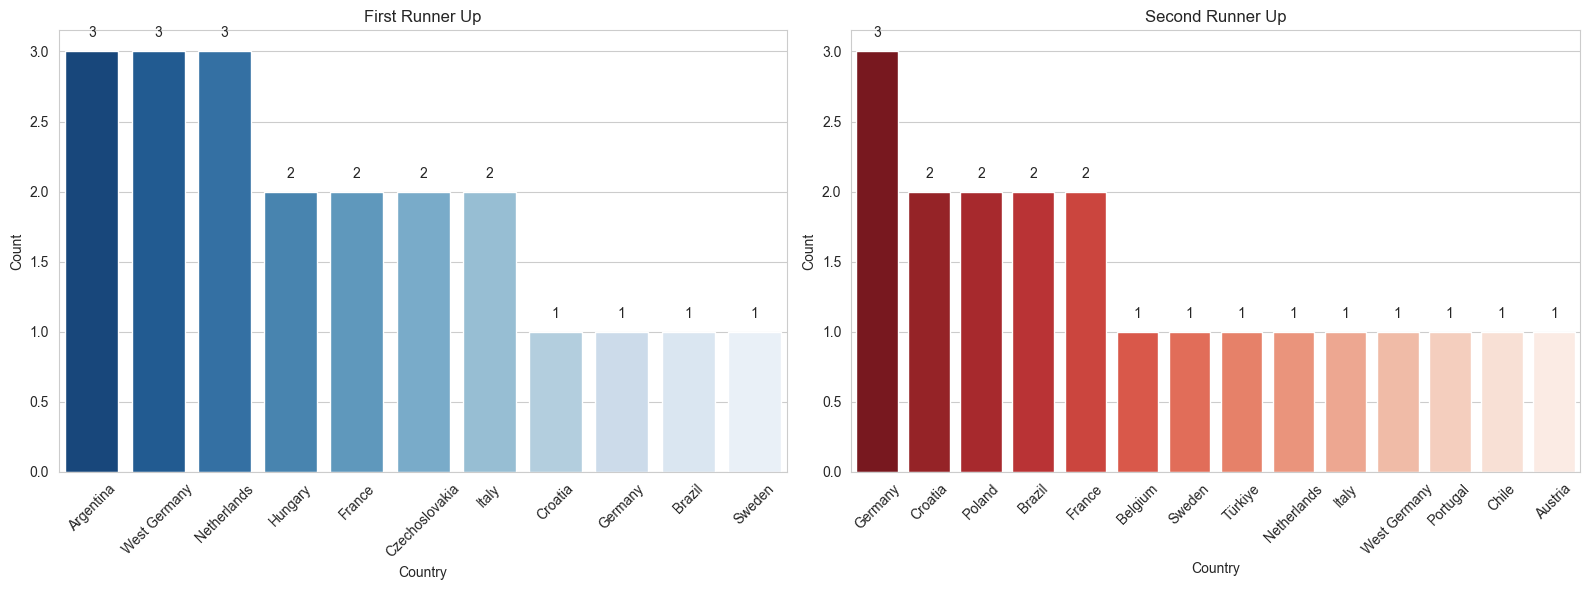

In [29]:
runner_counts = Runner['Runner_up'].value_counts().reset_index()
runner_counts.columns = ['Country', 'Count']

third_counts = Third['Third_place'].value_counts().reset_index()
third_counts.columns = ['Country', 'Count']


fig, axes = plt.subplots(1, 2, figsize=(16,6))


sns.barplot(data=runner_counts,x='Country',y='Count',ax=axes[0],palette='Blues_r')

axes[0].set_title('First Runner Up')
axes[0].tick_params(axis='x', rotation=45)

for i, v in enumerate(runner_counts['Count']):
    axes[0].text(i, v + 0.1, str(v), ha='center')


sns.barplot(data=third_counts,x='Country',y='Count',ax=axes[1],palette='Reds_r')

axes[1].set_title('Second Runner Up')
axes[1].tick_params(axis='x', rotation=45)

for i, v in enumerate(third_counts['Count']):
    axes[1].text(i, v + 0.1, str(v), ha='center')

plt.tight_layout()
plt.show()

### CONCLUSIONS

- Brazil won the most  number of titles followed by Italy and Argentina.

- Argentina , Netherland and West Germany won Most number of Runner up title.

- Germany was Second runnner up for most of the times.



# In which Year a Particular Team Participated.


In [30]:
data= matches.groupby('Year').agg(home=('home_team', list), away=('away_team', list))
data

,home,away
Year,,
1930,"[Uruguay, Uruguay, Argentina, Argentina, Urugu...","[Argentina, Yugoslavia, United States, Chile, ..."
1934,"[Italy, Germany, Czechoslovakia, Italy, Italy,...","[Czechoslovakia, Austria, Germany, Austria, Sp..."
1938,"[Brazil, Italy, Hungary, Italy, Brazil, Sweden...","[Sweden, Hungary, Sweden, Brazil, Czechoslovak..."
1950,"[Sweden, Uruguay, Brazil, Uruguay, Brazil, Uru...","[Spain, Brazil, Spain, Sweden, Sweden, Spain, ..."
1954,"[Germany, Austria, Hungary, Germany, Germany, ...","[Hungary, Uruguay, Uruguay, Austria, Yugoslavi..."
1958,"[Brazil, France, Sweden, Brazil, France, West ...","[Sweden, West Germany, West Germany, France, N..."
1962,"[Brazil, Chile, Brazil, Czechoslovakia, Chile,...","[Czechoslovakia, Yugoslavia, Chile, Yugoslavia..."
1966,"[England, Portugal, England, West Germany, Por...","[West Germany, Soviet Union, Portugal, Soviet ..."
1970,"[Brazil, West Germany, Italy, Brazil, Brazil, ...","[Italy, Uruguay, West Germany, Uruguay, Peru, ..."


In [31]:
data['teams']= data.apply(lambda x: list(set(x['home']+x['away'])), axis=1)

#1- concatinate
#2 - set ( duplicate X)
#3 - List


In [32]:
data['#']= data['teams'].apply(len)

In [34]:
data

,home,away,teams,#
Year,,,,
1930,"[Uruguay, Uruguay, Argentina, Argentina, Urugu...","[Argentina, Yugoslavia, United States, Chile, ...","[Argentina, Uruguay, Brazil, Mexico, Peru, Fra...",13
1934,"[Italy, Germany, Czechoslovakia, Italy, Italy,...","[Czechoslovakia, Austria, Germany, Austria, Sp...","[Egypt, Austria, Argentina, Germany, Brazil, S...",16
1938,"[Brazil, Italy, Hungary, Italy, Brazil, Sweden...","[Sweden, Hungary, Sweden, Brazil, Czechoslovak...","[Brazil, Germany, Switzerland, Hungary, Sweden...",15
1950,"[Sweden, Uruguay, Brazil, Uruguay, Brazil, Uru...","[Spain, Brazil, Spain, Sweden, Sweden, Spain, ...","[Uruguay, Brazil, Mexico, Switzerland, Sweden,...",13
1954,"[Germany, Austria, Hungary, Germany, Germany, ...","[Hungary, Uruguay, Uruguay, Austria, Yugoslavi...","[Austria, Türkiye, Uruguay, Germany, Brazil, K...",16
1958,"[Brazil, France, Sweden, Brazil, France, West ...","[Sweden, West Germany, West Germany, France, N...","[Austria, Argentina, Northern Ireland, Brazil,...",16
1962,"[Brazil, Chile, Brazil, Czechoslovakia, Chile,...","[Czechoslovakia, Yugoslavia, Chile, Yugoslavia...","[Colombia, Uruguay, Brazil, Argentina, Mexico,...",16
1966,"[England, Portugal, England, West Germany, Por...","[West Germany, Soviet Union, Portugal, Soviet ...","[Portugal, Uruguay, Argentina, West Germany, B...",16
1970,"[Brazil, West Germany, Italy, Brazil, Brazil, ...","[Italy, Uruguay, West Germany, Uruguay, Peru, ...","[Uruguay, Brazil, Peru, Mexico, West Germany, ...",16


In [35]:
data_pivot = data['teams'].explode().reset_index().pivot(index='Year', columns='teams', values='Year').T
data_pivot

Year,1930,1934,1938,1950,1954,1958,1962,1966,1970,1974,...,1986,1990,1994,1998,2002,2006,2010,2014,2018,2022
teams,,,,,,,,,,,,,,,,,,,,,
West Germany,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1974.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Algeria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1986.0,NaN,NaN,NaN,NaN,NaN,2010.0,2014.0,NaN,NaN
Angola,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2006.0,NaN,NaN,NaN,NaN
Argentina,1930.0,1934.0,NaN,NaN,NaN,1958.0,1962.0,1966.0,NaN,1974.0,...,1986.0,1990.0,1994.0,1998.0,2002.0,2006.0,2010.0,2014.0,2018.0,2022.0
Australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1974.0,...,NaN,NaN,NaN,NaN,NaN,2006.0,2010.0,2014.0,2018.0,2022.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Uruguay,1930.0,NaN,NaN,1950.0,1954.0,NaN,1962.0,1966.0,1970.0,1974.0,...,1986.0,1990.0,NaN,NaN,2002.0,NaN,2010.0,2014.0,2018.0,2022.0
Wales,NaN,NaN,NaN,NaN,NaN,1958.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022.0
West Germany,NaN,NaN,NaN,NaN,NaN,1958.0,1962.0,1966.0,1970.0,1974.0,...,1986.0,1990.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
data_pivot.fillna(0 , inplace=True)

In [37]:
data_pivot= data_pivot.applymap(lambda x: 1 if x>0 else 0)

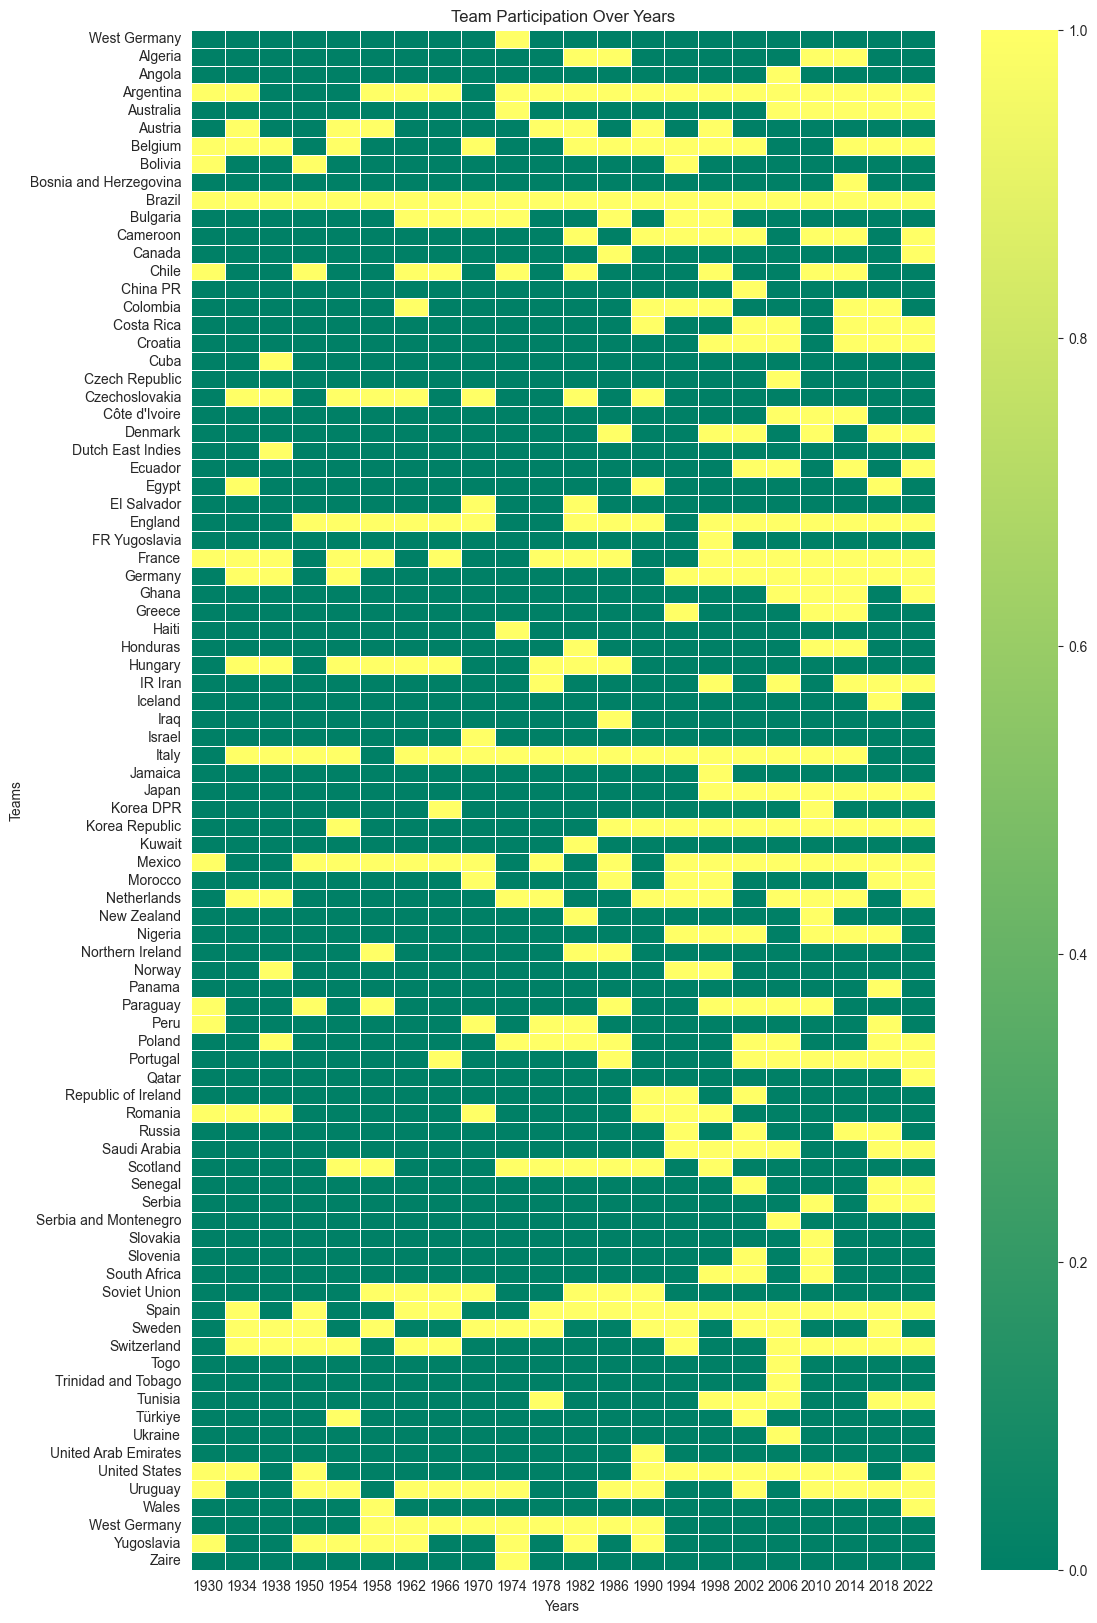

In [38]:
plt.figure(figsize=(12,20))
sns.heatmap(data_pivot,linewidths= 0.5, linecolor='white',cmap="summer")
plt.title("Team Participation Over Years")
plt.xlabel("Years")
plt.ylabel("Teams")
plt.show()


### OBSERVATIONS
- Brazil is the only country to play all editions of the FIFA cup.

- Countries are Qatar , Canada , Wales are new to the tournament.

- Countires like Cuba, Israel , Kuwait , jamaica, Ukrain , Tongo etc. participated in only 1 edition of FIFA.

# CHECKING FOR WHICH TEAM RANK INCREASED , DECREASED OR REMAIN SAME.

In [39]:
Same_rank= world_ranking[world_ranking['rank']==world_ranking['previous_rank']]['team'].tolist()
Rank_decreased = world_ranking[world_ranking['rank']>world_ranking['previous_rank']]['team'].tolist()
Rank_increased = world_ranking[world_ranking['rank']<world_ranking['previous_rank']]['team'].tolist()

In [40]:
print(f"Same Rank : {len(Same_rank)}")
print(f"Rank Increased : {len(Rank_increased)}")
print(f"Rank Decreased : {len(Rank_decreased)}")

Same Rank : 66
Rank Increased : 77
Rank Decreased : 68


In [41]:
max_length= max(len(Same_rank), len(Rank_increased), len(Rank_decreased))

In [42]:
Same_rank += [None]*(max_length-len(Same_rank))
Rank_increased += [None]*(max_length-len(Rank_increased))
Rank_decreased += [None]*(max_length-len(Rank_decreased))

In [43]:
df= pd.DataFrame({
    "Same Rank": Same_rank,
    "Rank Increased": Rank_increased,
    "Rank Decreased": Rank_decreased
})
df

,Same Rank,Rank Increased,Rank Decreased
0,Brazil,Italy,Spain
1,Belgium,Croatia,Mexico
2,Argentina,Switzerland,Uruguay
3,France,IR Iran,USA
4,England,Serbia,Peru
...,...,...,...
72,None,Timor-Leste,None
73,None,Eritrea,None
74,None,Aruba,None
75,None,Bahamas,None


In [44]:
df.isnull().sum()

Same Rank         11
Rank Increased     0
Rank Decreased     9
dtype: int64

In [45]:
df.fillna('', inplace=True)

In [46]:
#Function to check rank increase or decrease.

def find_Rank(Country):
    result = []
    for column in df.columns:
        matches = df[column] == Country
        if matches.any():
            result.append(column)
    return result

In [47]:
find_Rank("Belgium")

['Same Rank']

# ADVANCE EDA

# PROBABILITY OF A TEAM WINNING KNOCKOUT MATCHES

In [48]:
country ='Argentina'

#final
#semi final
#quarter final



In [49]:
matches['Round'].unique()

array(['Final', 'Third-place match', 'Semi-finals', 'Quarter-finals',
       'Round of 16', 'Group stage', 'Second group stage',
       'First group stage', 'Second round', 'First round',
       'Group stage play-off', 'Final stage'], dtype=object)

In [50]:
data = matches[((matches['home_team']==country) | (matches['away_team']==country))&
        ((matches['Round']=='Final') | (matches['Round']=='Semi-finals') | (matches['Round']=='Quarter-finals'))]

In [51]:
df1= data['Round'].value_counts().reset_index()
df1.columns=['Round',"Total Matches"]

In [52]:
#Functions to  determine the Winner of each game
def get_winner(row):
  if row['h_total']>row['a_total']:
    return row['home_team']
  else:
    return row['away_team']

In [53]:
data['Winner']= data.apply(get_winner, axis=1)

In [54]:
df2= data[data['Winner']==country]['Round'].value_counts().reset_index()
df2.columns=['Round',"Total Matches"]

In [55]:
pd.merge(df1, df2, on='Round', how='inner')

,Round,Total Matches_x,Total Matches_y
0,Quarter-finals,8,4
1,Final,6,3
2,Semi-finals,5,5


In [56]:
def calculate_performance(country):
    
    # Filter matches based on the specified country and rounds
    data = matches[((matches['home_team'] == country) | (matches['away_team'] == country)) &
                   ((matches['Round'] == 'Final') | (matches['Round'] == 'Semi-finals') | (matches['Round'] == 'Quarter-finals'))]

    # Create a DataFrame with the count of matches per round
    df1 = pd.DataFrame(data['Round'].value_counts().reset_index())
    df1.columns = ['Round', 'Total Matches']

    # Function to determine the winner of each match
    def get_winner(row):
        if row['h_total'] > row['a_total']:
            return row['home_team']
        else:
            return row['away_team']

    # Apply the function to determine the winner for each match
    data['Winner'] = data.apply(get_winner, axis=1)

    # Create a DataFrame with the count of matches won by the specified country per round
    df2 = pd.DataFrame(data[data['Winner'] == country]['Round'].value_counts().reset_index())
    df2.columns = ['Round', 'Matches Won']

    # Merge the two DataFrames on the 'Round' column
    result = pd.merge(df1, df2, on='Round', how='inner')

    # Calculate the percentage of matches won
    result['Percentage'] = (result['Matches Won'] / result['Total Matches']) * 100

    return result




In [58]:
calculate_performance('Italy')

,Round,Total Matches,Matches Won,Percentage
0,Quarter-finals,8,6,75.000000
1,Semi-finals,7,6,85.714286
2,Final,6,4,66.666667


### CONCLUSIONS

- Italy: Teams facing Italy in knockout rounds can expect a challenging match. Italy has a 75% probability of winning in the quarter-finals, an 86% probability of advancing from the semi-finals, and a 67% probability of securing victory in the finals.

- Spain - if it clears QF its wins title.
- France - they have good record in QF  comparatively not that good record in Semi and Finals.


- Sweden never reaches a final.

- if Argentina reaches semi final , it will surely win it.

# CHECKING PLAYING STRATEGY OF  TEAMS IN KNOCKOUT V/S NON-KNOCKOUT MATCHES

In [59]:
matches['home_goal'][0]

'Ángel Di María · 36|Lionel Messi · 108'

In [60]:
import re

In [61]:
pattern = r'\b(\d+)\b'

In [62]:
#Function to extract time from each row  for home_team

def extract_time(row):
  if pd.notna(row['home_goal']):
    goal_str= str(row['home_goal'])
    times=[]
    matches= re.findall(pattern, goal_str)
    times.extend(matches)
    return ', '.join(times)
  else:
    return ''


In [63]:
matches['Home_Goals']= matches.apply(extract_time, axis=1)

In [64]:
#Function to extract time from each row  for away team

def extract_time(row):
  if pd.notna(row['away_goal']):
    goal_str= str(row['away_goal'])
    times=[]
    matches= re.findall(pattern, goal_str)
    times.extend(matches)
    return ', '.join(times)
  else:
    return ''

In [65]:
matches['Away_Goals']= matches.apply(extract_time, axis=1)

In [67]:
country

'Argentina'

In [68]:
#CHECKING FOR KNOCKOUTS OR NOT

knockout_rounds= ['Final', 'Semi-finals', 'Quarter-finals']

matches['Knockout']= matches['Round'].apply(lambda x : 'Knockout' if x in knockout_rounds else 'Non-Knockout')

In [69]:
country= 'Romania'

In [70]:
home_k = matches[(matches['home_team']==country)&(matches['Knockout']== 'Knockout')]
away_k = matches[(matches['away_team']==country)&(matches['Knockout']== 'Knockout')]


home_nk = matches[(matches['home_team']==country)&(matches['Knockout']== 'Non-Knockout')]
away_nk = matches[(matches['away_team']==country)&(matches['Knockout']== 'Non-Knockout')]

In [71]:
#FOR KNOCKOUT MATCHES

a=home_k['Home_Goals'].str.split(',').explode().reset_index()
b=away_k['Away_Goals'].str.split(',').explode().reset_index()

df1= pd.concat([a,b], axis=0, ignore_index=True)
df1.replace(r'^\s*$', 0, regex=True, inplace=True)
df1.fillna(0 ,inplace= True)


df1['Home_Goals']= df1['Home_Goals'].astype(int)
df1['Away_Goals']= df1['Away_Goals'].astype(int)

df1['Time']= df1['Home_Goals']+df1['Away_Goals']
df1= df1[df1['Time']!=0]

def determine(row):
  if(row['Time']<=45):
    return("First Half")
  elif(row['Time']>45 and row['Time']<=90):
    return("Second Half")
  else:
    return("Extra Time")

df1['time']= df1.apply(determine, axis=1)

In [72]:
df1['time'].value_counts()/len(df1)*100

time
Second Half    50.0
Extra Time     50.0
Name: count, dtype: float64

In [73]:
# FOR NON-KNOCKOUT GAMES
a=home_nk['Home_Goals'].str.split(',').explode().reset_index()
b=away_nk['Away_Goals'].str.split(',').explode().reset_index()

df2= pd.concat([a,b], axis=0, ignore_index=True)
df2.replace(r'^\s*$', 0, regex=True, inplace=True)
df2.fillna(0 ,inplace= True)


df2['Home_Goals']= df2['Home_Goals'].astype(int)
df2['Away_Goals']= df2['Away_Goals'].astype(int)

df2['Time']= df2['Home_Goals']+df2['Away_Goals']
df2= df2[df2['Time']!=0]

def determine(row):
  if(row['Time']<=45):
    return("First Half")
  elif(row['Time']>45 and row['Time']<=90):
    return("Second Half")
  else:
    return("Extra Time")

df2['time']= df2.apply(determine, axis=1)

In [74]:
df2['time'].value_counts()/len(df2)*100

time
First Half     50.000000
Second Half    46.153846
Extra Time      3.846154
Name: count, dtype: float64

### CONCLUSION

- Generally teams play more agressive in 2nd half as compared to first half be it knockout or non- knockout tournaments.

- In knockout Tournaments , Mexico only scored in First half, either they are defending in second half and maintaining the lead.

- In knockout Tournaments countries Romaniya , Pero play with same agression in both the halves of the game.

- Spain have very different strategy they place with almost equal agression in non knockout matches , however in knowckout matches they follow different plan , on first half they are into passive state (not scoring much) , however in second half they retaliate very voilently. Infact goals scored by them in first half and extra time are equal in number.


- Canada never reached a knowckout stage , and even in non knockout stages they never scored a goal in second half. This can be their  scope of improvement area , as they not scoring in the second half may be the reason they never made it to knockouts.

# DOES SUBSTITUTION TURNS OUT TO BE FRUITFULL  OR NOT FOR THE TEAM.


#fruitfull --- substituted player score
 #         ---  Overall Score Improve

In [75]:
matches['home_substitute_in_long'][0]



# in player ---- did he scored
# substituion time ---- does the score improved.


# we will use re library.

"['64&rsquor;|2:0|Marcos Acuña|for Ángel Di María', '91&rsquor;|2:2|Gonzalo Montiel|for Nahuel Molina', '102&rsquor;|2:2|Leandro Paredes|for Rodrigo De Paul', '103&rsquor;|2:2|Lautaro Martínez|for Julián Álvarez', '116&rsquor;|3:2|Germán Pezzella|for Alexis Mac Allister', '120+1&rsquor;|3:3|Paulo Dybala|for Nicolás Tagliafico']"

In [77]:
matches_df= pd.read_csv('matches_1930_2022.csv')

In [78]:
matches_df

,home_team,away_team,home_score,home_xg,home_penalty,away_score,away_xg,away_penalty,home_manager,home_captain,...,home_penalty_shootout_miss_long,away_penalty_shootout_miss_long,home_red_card,away_red_card,home_yellow_red_card,away_yellow_red_card,home_yellow_card_long,away_yellow_card_long,home_substitute_in_long,away_substitute_in_long
0,Argentina,France,3,3.3,4.0,3,2.2,2.0,Lionel Scaloni,Lionel Messi,...,NaN,"['3|1:1|Kingsley Coman', '5|2:1|Aurélien Tchou...",NaN,NaN,NaN,NaN,"['45+7&rsquor;|2:0|Enzo Fernández', '90+8&rsqu...","['55&rsquor;|2:0|Adrien Rabiot', '87&rsquor;|2...",['64&rsquor;|2:0|Marcos Acuña|for Ángel Di Mar...,['41&rsquor;|2:0|Randal Kolo Muani|for Ousmane...
1,Croatia,Morocco,2,0.7,NaN,1,1.2,NaN,Zlatko Dalić,Luka Modrić,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['69&rsquor;|2:1|Azzedine Ounahi', '84&rsquor;...",['61&rsquor;|2:1|Nikola Vlašić|for Andrej Kram...,['46&rsquor;|2:1|Ilias Chair|for Abdelhamid Sa...
2,France,Morocco,2,2.0,NaN,0,0.9,NaN,Didier Deschamps,Hugo Lloris,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['27&rsquor;|1:0|Sofiane Boufal'],['65&rsquor;|1:0|Marcus Thuram|for Olivier Gir...,['21&rsquor;|1:0|Selim Amallah|for Romain Saïs...
3,Argentina,Croatia,3,2.3,NaN,0,0.5,NaN,Lionel Scaloni,Lionel Messi,...,NaN,NaN,NaN,NaN,NaN,NaN,"['68&rsquor;|2:0|Cristian Romero', '71&rsquor;...","['32&rsquor;|0:0|Mateo Kovačić', '32&rsquor;|0...",['62&rsquor;|2:0|Lisandro Martínez|for Leandro...,"['46&rsquor;|2:0|Mislav Oršić|for Borna Sosa',..."
4,Morocco,Portugal,1,1.4,NaN,0,0.9,NaN,Hoalid Regragui,Romain Saïss,...,NaN,NaN,NaN,NaN,Walid Cheddira · 90+3,NaN,"['70&rsquor;|1:0|Achraf Dari', '90+1&rsquor;|1...",['87&rsquor;|1:0|Vitinha'],['57&rsquor;|1:0|Achraf Dari|for Romain Saïss'...,['51&rsquor;|1:0|João Cancelo|for Raphaël Guer...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
959,Argentina,France,1,NaN,NaN,0,NaN,NaN,Francisco Olazar,Manuel Ferreira,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
960,Yugoslavia,Brazil,2,NaN,NaN,1,NaN,NaN,Bosko Simonovic,Milutin Ivković,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
961,Romania,Peru,3,NaN,NaN,1,NaN,NaN,Octav Luchide,Emerich Vogl,...,NaN,NaN,NaN,Plácido Galindo · 70,NaN,NaN,NaN,NaN,NaN,NaN
962,United States,Belgium,3,NaN,NaN,0,NaN,NaN,Bob Millar,Tom Florie,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [79]:
# Parse substituion column function
def parse_substitution_data(subs):
    if pd.isna(subs):
        return []
    pattern = r"(\d+)&rsquor;\|(.+?)\|for (.+?)(?=\||$)"
    matches = re.findall(pattern, subs)   #return a tuple , of time , player in ,player out.
    return [{'minute': int(match[0]), 'player_in': match[1], 'player_out': match[2]} for match in matches]


In [80]:
matches_df['home_substitute_in_long'].apply(parse_substitution_data)[0]

[{'minute': 64,
  'player_in': '2:0|Marcos Acuña',
  'player_out': "Ángel Di María', '91&rsquor;"},
 {'minute': 102,
  'player_in': '2:2|Leandro Paredes',
  'player_out': "Rodrigo De Paul', '103&rsquor;"},
 {'minute': 116,
  'player_in': '3:2|Germán Pezzella',
  'player_out': "Alexis Mac Allister', '120+1&rsquor;"}]

In [81]:
matches_df['home_substitutions'] = matches_df['home_substitute_in_long'].apply(parse_substitution_data)
matches_df['away_substitutions'] = matches_df['away_substitute_in_long'].apply(parse_substitution_data)

# did this substitute scored a goal or improved performance

In [82]:
# Parsing Goal Data
def  parse_goal_data(goals):
  if pd.isna(goals):
    return []


  goal_list = goals.split('|')
  parsed_goals=[]
  for goal in goal_list:
    parts= goal.split('·')   #middle dot or interpunct  (alt+0183)[ number pad]
    if(len(parts)==2):
        try:
           minute = int(parts[1].strip())
           scorer= parts[0].strip()
           parsed_goals.append({'minute': minute, 'scorer': scorer})
        except ValueError:
          pass
  return parsed_goals


In [83]:
matches_df['home_goal_details']=matches['home_goal'].apply(parse_goal_data)
matches_df['away_goal_details']=matches['away_goal'].apply(parse_goal_data)

In [84]:
# i know which player was substituted
# which player scored and at which time.

In [85]:
def filter_matches_for_team(df, team_name):
  team_matches= df[(df['home_team'] == team_name) | (df['away_team'] == team_name)].copy()
  return team_matches

In [86]:
team_name= 'Germany'
team_matches_df= filter_matches_for_team(matches_df, team_name)

In [87]:
team_matches_df

,home_team,away_team,home_score,home_xg,home_penalty,away_score,away_xg,away_penalty,home_manager,home_captain,...,home_yellow_red_card,away_yellow_red_card,home_yellow_card_long,away_yellow_card_long,home_substitute_in_long,away_substitute_in_long,home_substitutions,away_substitutions,home_goal_details,away_goal_details
22,Costa Rica,Germany,2,1.3,NaN,4,5.7,NaN,Luis Fernando Suárez,Keylor Navas,...,NaN,NaN,['77&rsquor;|2:2|Óscar Duarte'],NaN,['46&rsquor;|0:1|Youstin Salas|for Brandon Agu...,['46&rsquor;|0:1|Lukas Klostermann|for Leon Go...,"[{'minute': 46, 'player_in': '0:1|Youstin Sala...","[{'minute': 46, 'player_in': '0:1|Lukas Kloste...","[{'minute': 58, 'scorer': 'Yeltsin Tejeda'}]","[{'minute': 10, 'scorer': 'Serge Gnabry'}, {'m..."
39,Spain,Germany,1,0.6,NaN,1,1.3,NaN,Luis Enrique,Sergio Busquets,...,NaN,NaN,['44&rsquor;|0:0|Sergio Busquets'],"['37&rsquor;|0:0|Thilo Kehrer', '58&rsquor;|0:...",['54&rsquor;|0:0|Álvaro Morata|for Ferrán Torr...,['70&rsquor;|1:0|Lukas Klostermann|for Thilo K...,"[{'minute': 54, 'player_in': '0:0|Álvaro Morat...","[{'minute': 70, 'player_in': '1:0|Lukas Kloste...","[{'minute': 62, 'scorer': 'Álvaro Morata'}]","[{'minute': 83, 'scorer': 'Niclas Füllkrug'}]"
53,Germany,Japan,1,3.1,NaN,2,1.5,NaN,Hansi Flick,Manuel Neuer,...,NaN,NaN,NaN,NaN,['67&rsquor;|1:0|Jonas Hofmann|for Thomas Müll...,['46&rsquor;|1:0|Takehiro Tomiyasu|for Takefus...,"[{'minute': 67, 'player_in': '1:0|Jonas Hofman...","[{'minute': 46, 'player_in': '1:0|Takehiro Tom...",[],"[{'minute': 75, 'scorer': 'Ritsu Doan'}, {'min..."
84,Korea Republic,Germany,2,1.7,NaN,0,2.7,NaN,Shin Taeyong,Son Heung-min,...,NaN,NaN,"['9&rsquor;|0:0|Jung Woo-young', '23&rsquor;|0...",NaN,['56&rsquor;|0:0|Hwang Hee-chan|for Koo Ja-che...,['58&rsquor;|0:0|Mario Gómez|for Sami Khedira'...,"[{'minute': 56, 'player_in': '0:0|Hwang Hee-ch...","[{'minute': 58, 'player_in': '0:0|Mario Gómez'...",[],[]
101,Germany,Sweden,2,1.4,NaN,1,0.9,NaN,Joachim Löw,Manuel Neuer,...,Jérôme Boateng · 82,NaN,['71&rsquor;|1:1|Jérôme Boateng'],"['52&rsquor;|1:1|Albin Ekdal', '90+7&rsquor;|2...",['31&rsquor;|0:0|İlkay Gündoğan|for Sebastian ...,['74&rsquor;|1:1|Jimmy Durmaz|for Viktor Claes...,"[{'minute': 31, 'player_in': '0:0|İlkay Gündoğ...","[{'minute': 74, 'player_in': '1:1|Jimmy Durmaz...","[{'minute': 48, 'scorer': 'Marco Reus'}]","[{'minute': 32, 'scorer': 'Ola Toivonen'}]"
118,Germany,Mexico,0,1.4,NaN,1,1.3,NaN,Joachim Löw,Manuel Neuer,...,NaN,NaN,"['83&rsquor;|0:1|Thomas Müller', '84&rsquor;|0...","['40&rsquor;|0:1|Héctor Moreno', '90&rsquor;|0...","['60&rsquor;|0:1|Marco Reus|for Sami Khedira',...",['58&rsquor;|0:1|Edson Álvarez|for Carlos Vela...,"[{'minute': 60, 'player_in': '0:1|Marco Reus',...","[{'minute': 58, 'player_in': '0:1|Edson Álvare...",[],"[{'minute': 35, 'scorer': 'Hirving Lozano'}]"
128,Germany,Argentina,1,NaN,NaN,0,NaN,NaN,Joachim Löw,NaN,...,NaN,NaN,"['29&rsquor;|0:0|Bastian Schweinsteiger', '34&...","['64&rsquor;|0:0|Javier Mascherano', '65&rsquo...",['32&rsquor;|0:0|André Schürrle|for Christoph ...,['46&rsquor;|0:0|Sergio Agüero|for Ezequiel La...,"[{'minute': 32, 'player_in': '0:0|André Schürr...","[{'minute': 46, 'player_in': '0:0|Sergio Agüer...","[{'minute': 113, 'scorer': 'Mario Götze'}]",[]
131,Brazil,Germany,1,NaN,NaN,7,NaN,NaN,Luiz Felipe Scolari,NaN,...,NaN,NaN,['68&rsquor;|0:5|Dante'],NaN,"['46&rsquor;|0:5|Paulinho|for Hulk', '46&rsquo...",['46&rsquor;|0:5|Per Mertesacker|for Mats Humm...,"[{'minute': 46, 'player_in': '0:5|Paulinho', '...","[{'minute': 46, 'player_in': '0:5|Per Mertesac...","[{'minute': 90, 'scorer': 'Oscar'}]","[{'minute': 11, 'scorer': 'Thomas Müller'}, {'..."
134,France,Germany,0,NaN,NaN,1,NaN,NaN,Didier Deschamps,NaN,...,NaN,NaN,NaN,"['54&rsquor;|0:1|Sami Khedira', '80&rsquor;|0:...",['72&rsquor;|0:1|Laurent Koscielny|for Mamadou...,['69&rsquor;|0:1|André Schürrle|for Miroslav K...,"[{'minute': 72, 'player_in': '0:1|Laurent Kosc...","[{'minute': 69, 'player_in': '0:1|André Schürr...",[],"[{'minute': 13, 'scorer': '

In [88]:
# if substituted Player scored a goal
# we will create two functions.

#subs- list {substituions}
#goals- list {goals}

def check_substitute_goals(subs, goals):
    if not subs:
        return
    for sub in subs:
        if any(goal['scorer'] == sub['player_in'] for goal in goals):
            return True
    return False



def check_team_substitute_goals(row, team_name):
    if row['home_team'] == team_name:
        return check_substitute_goals(row['home_substitutions'], row['home_goal_details'])
    elif row['away_team'] == team_name:
        return check_substitute_goals(row['away_substitutions'], row['away_goal_details'])
    return False

In [89]:
# Determine if substitution improved the score
def check_substitution_impact(row, team_name):
    if row['home_team'] == team_name:
        subs = row['home_substitutions']
        goals_before = [goal for goal in row['home_goal_details'] if subs and goal['minute'] <= subs[0]['minute']] if subs else []
        goals_after = [goal for goal in row['home_goal_details'] if subs and goal['minute'] > subs[0]['minute']] if subs else []
    elif row['away_team'] == team_name:
        subs = row['away_substitutions']
        goals_before = [goal for goal in row['away_goal_details'] if subs and goal['minute'] <= subs[0]['minute']] if subs else []
        goals_after = [goal for goal in row['away_goal_details'] if subs and goal['minute'] > subs[0]['minute']] if subs else []
    else:
        return False


    return len(goals_after) > len(goals_before)

In [90]:
team_matches_df['substitution_impact'] = team_matches_df.apply(lambda row: check_substitution_impact(row, team_name), axis=1)
team_matches_df['substitute_goals'] = team_matches_df.apply(lambda row: check_team_substitute_goals(row, team_name), axis=1)

In [91]:
match_summaries = []

for index, row in team_matches_df.iterrows():
    match_summary = {
        'Match': f"{row['home_team']} vs {row['away_team']}",
        'Date': row['Date'],
        'Substitute Scored': row['substitute_goals'],
        'Substitution Impact': row['substitution_impact']
    }
    match_summaries.append(match_summary)


In [92]:
summary_df = pd.DataFrame(match_summaries)

In [93]:
print(summary_df['Substitute Scored'].value_counts())
print('***')
print(summary_df['Substitution Impact'].value_counts())

Substitute Scored
False    44
Name: count, dtype: int64
***
Substitution Impact
False    41
True     15
Name: count, dtype: int64


### CONCLUSIONS

- No Team substituted player scored goal in FIFA.

- Teams like France , Argentina , Portugal , Australia , Germany , Spain , Netherland have very  high or positive impact of subsutituion on overall score of the team.

- Positive impact of the substituion signifies that these teams have a strong management that act accourdingly , as these teams are also the top teams of FIFA, these effective substution may be  one of the reason why these teams are most favourite teams of the world.

- A team can rely on substituted player for overall improvement of score but not for the goals to be scored by substituted player.

In [94]:
#Team expected Performance and Actual Performance

In [95]:
#Calculate expected goals  and total goals for  each team

home_team_stats= matches.groupby(['home_team','Year']).agg({
    'home_score':'sum',
    'home_xg' :'sum'
}).rename(columns={'home_score':'Total_goals'})

away_team_stats= matches.groupby(['away_team','Year']).agg({
    'away_score':'sum',
    'away_xg' :'sum'
}).rename(columns={'away_score':'Total_goals'})

In [96]:
home_team_stats= home_team_stats.reset_index()
away_team_stats= away_team_stats.reset_index()


home_team_stats= home_team_stats[(home_team_stats['Year']==2018 )|(home_team_stats['Year']==2022)]
away_team_stats= away_team_stats[(away_team_stats['Year']==2018 )|(away_team_stats['Year']==2022)]

In [97]:
home_team_stats.rename(columns= {'home_team':'team'}, inplace=True)
away_team_stats.rename(columns= {'away_team':'team'}, inplace=True)

In [98]:
merged= pd.merge(home_team_stats, away_team_stats, on=['team','Year'], how='inner')

In [99]:
merged['Total_goals']= merged['Total_goals_x']+merged['Total_goals_y']
merged['Total_xg']= merged['home_xg']+merged['away_xg']
merged['Deviation']=merged['Total_xg']-merged['Total_goals']

In [100]:
merged[merged['Year']==2018]

,team,Year,Total_goals_x,home_xg,Total_goals_y,away_xg,Total_goals,Total_xg,Deviation
0,Argentina,2018,1,3.2,5,1.7,6,4.9,-1.1
2,Australia,2018,0,0.9,2,2.3,2,3.2,1.2
4,Belgium,2018,13,11.2,3,2.2,16,13.4,-2.6
6,Brazil,2018,6,10.3,2,1.4,8,11.7,3.7
10,Colombia,2018,2,1.6,4,2.4,6,4.0,-2.0
11,Costa Rica,2018,0,0.9,2,1.6,2,2.5,0.5
13,Croatia,2018,5,5.7,9,5.4,14,11.1,-2.9
15,Denmark,2018,1,1.0,2,1.9,3,2.9,-0.1
18,Egypt,2018,0,0.3,2,2.2,2,2.5,0.5
19,England,2018,6,3.7,6,7.5,12,11.2,-0.8


### CONCLUSION.

- IN 2018 , Argentina Failed to take home advantages and underperformed in home games , However they over performed in non home grounds.

- In 2018 Russia Was the most attacking team , as they scored 60% more goals  then they were expected to score , this may be due to home condition advantage as in 2018 FIFA world cup was in Russia.

- Russia  was also the Underdog Team in 2018 , as it performed much more than expected.

- Netherland was the underdog team of  2022, it scored  52% more goals than expected.

- Among top teams Portugal scored  40% more than expected goals.

- Most Overrated team of 2018 and 2022 was Brazil  they scored
 32%  and 40% less goals than expected in  2018 and 2022 respectively.